## Inversion for a coupled acoustic-gravity system

Before running `pip install tinyda ray' 

### Problem setup

Let $\varphi$ be the potential for the flow velocity, it is solution to 
\begin{align}
    \frac{\partial {\bf u}}{\partial t}
    - \nabla \left(
    \frac{1}{ \rho} \psi
    \right) = 0 \quad \text{ in } \Omega,
    \\
    \frac{\partial \psi}{\partial t}
    - \nabla \cdot( \rho {\bf u}) = 0 \quad \text{ in } \Omega,
    \\
    \frac{1}{ \rho} \frac{\partial \psi}{\partial t}
    + \delta^2  {\bf u} \cdot {\bf e}_z = 0 \quad \text{ on } \Gamma_s,
    \\
    {\bf u} \cdot {\bf n} = u_b, \quad \text{ on } \Gamma_b,
    \\
    {\bf u} \cdot {\bf n} + \frac{1}{\rho} \psi = 0 \qquad \text{on} \quad \Gamma_\ell.
\end{align}
where $c$ is the (constant) sound speed, $g$ is the gravity acceleration, ${\bf n}$ is the outwards unit vector normal to the seabed $\Gamma_b$ and $u_b$ is the seabed velocity.
The fluid displacement $u$ is related to the potential by $u = \nabla \varphi$.

In [1]:
import matplotlib.cm as cm
import matplotlib.colors as colors
from scipy.stats import multivariate_normal
from scipy.spatial.distance import cdist

import tinyDA as tda
import umbridge

/home/dubois/miniconda3/envs/umbridge/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-24 09:50:33,011	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


# Load data and get stats

In [24]:
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# convert the tinyDA chains to an ArViz InferenceData object.
folder_data = "../../../../data_from_cluster/2026_08/"
# filename = "2026_08_20_envelope" 
# filename = "results_dg_8000"
# filename = "results_dg_wasserstein_4000"
# filename = "results_dg_4000_sigma0.0000"
# filename = "wasserstein_not_adapt_1500"
filename = "wasserstein_adapt_1500"
idata = az.from_netcdf(folder_data+filename+".nc") # to load

/home/dubois/miniconda3/envs/umbridge/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


In [77]:
print(idata)
print(idata.sample_stats)

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> qoi
<xarray.Dataset> Size: 128kB
Dimensions:     (chain: 1, draw: 4001)
Coordinates:
  * chain       (chain) int64 8B 0
  * draw        (draw) int64 32kB 0 1 2 3 4 5 ... 3995 3996 3997 3998 3999 4000
Data variables:
    prior       (chain, draw) float64 32kB ...
    likelihood  (chain, draw) float64 32kB ...
    posterior   (chain, draw) float64 32kB ...


In [78]:
# display posterior summary statistics.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)
info = az.summary(idata);
info

arviz - WARNING - Shape validation failed: input_shape: (1, 4001), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
x0,-0.145,0.938,-1.992,1.389,0.062,0.044,233.0,314.0,NaN
x1,-0.217,0.950,-2.188,1.326,0.066,0.046,212.0,272.0,NaN
x2,-0.288,0.973,-2.115,1.390,0.071,0.051,184.0,240.0,NaN
x3,-0.325,0.995,-1.906,1.631,0.077,0.055,164.0,230.0,NaN
x4,-0.367,1.003,-1.900,1.772,0.078,0.056,162.0,219.0,NaN
x5,-0.404,0.999,-2.111,1.507,0.074,0.053,172.0,225.0,NaN
x6,-0.455,0.950,-2.043,1.461,0.058,0.041,261.0,548.0,NaN
x7,-0.484,0.906,-2.216,1.074,0.045,0.032,405.0,563.0,NaN
x8,-0.523,0.886,-2.294,0.914,0.043,0.031,425.0,579.0,NaN
x9,-0.540,0.871,-2.301,0.969,0.043,0.030,403.0,535.0,NaN


/home/dubois/miniconda3/envs/umbridge/lib/python3.12/site-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (100), generating only 20 plots
  warnings.warn(


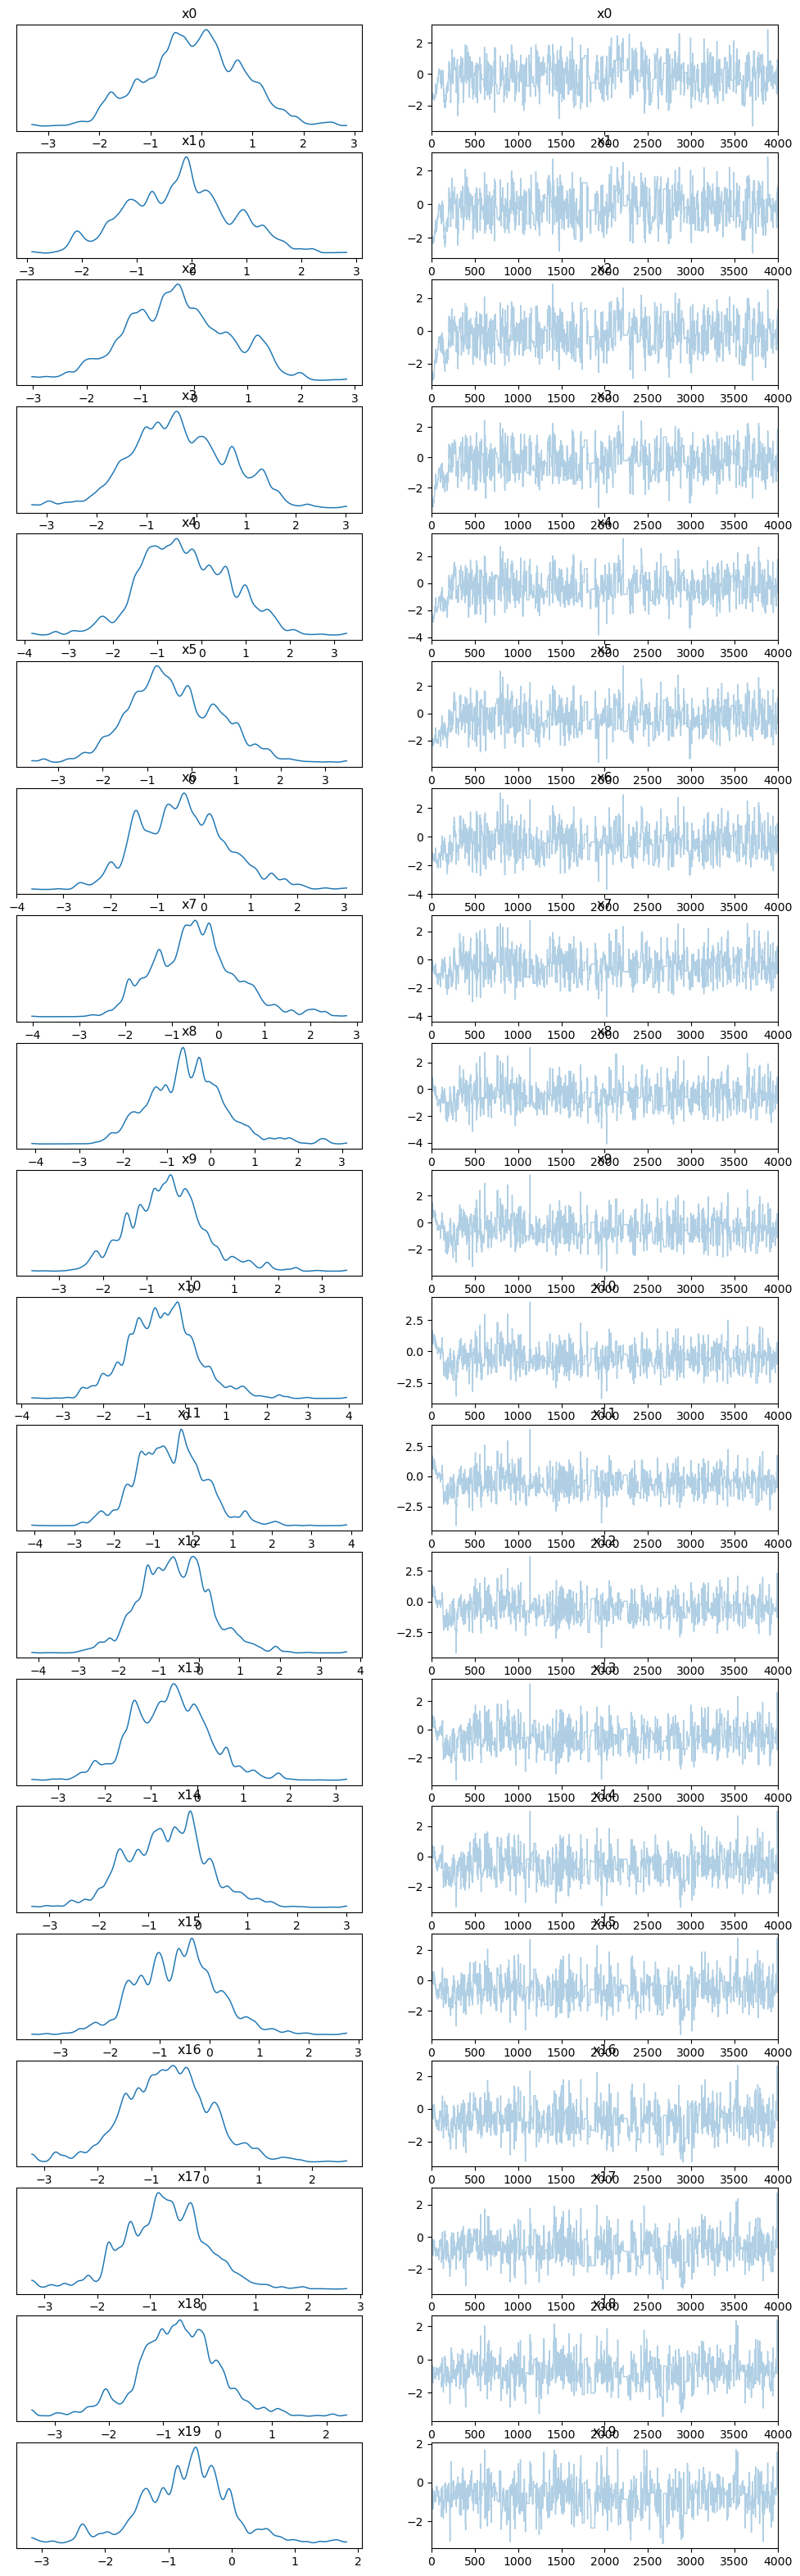

In [79]:
# plot posterior kernel densities and traces.
az.plot_trace(idata)
plt.show()

In [80]:
# extract the parameters from the chains.
subsampling_rate = 1
burnin = 500
#parameters = [link.parameters for link in my_chains['chain_0'][burnin::subsampling_rate] + my_chains['chain_1'][burnin::subsampling_rate]]

# If loaded data need to do this, otherwise above is easier
idata_sub = idata.sel(draw=slice(burnin, None, subsampling_rate))
parameters = [
    np.array([idata_sub.posterior[var].values[0, i] for var in idata_sub.posterior.data_vars])
    for i in range(idata_sub.posterior.draw.size)
]

/home/dubois/miniconda3/envs/umbridge/lib/python3.12/site-packages/arviz/plots/plot_utils.py:272: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (200) in plot_autocorr, generating only 40 plots
  warnings.warn(


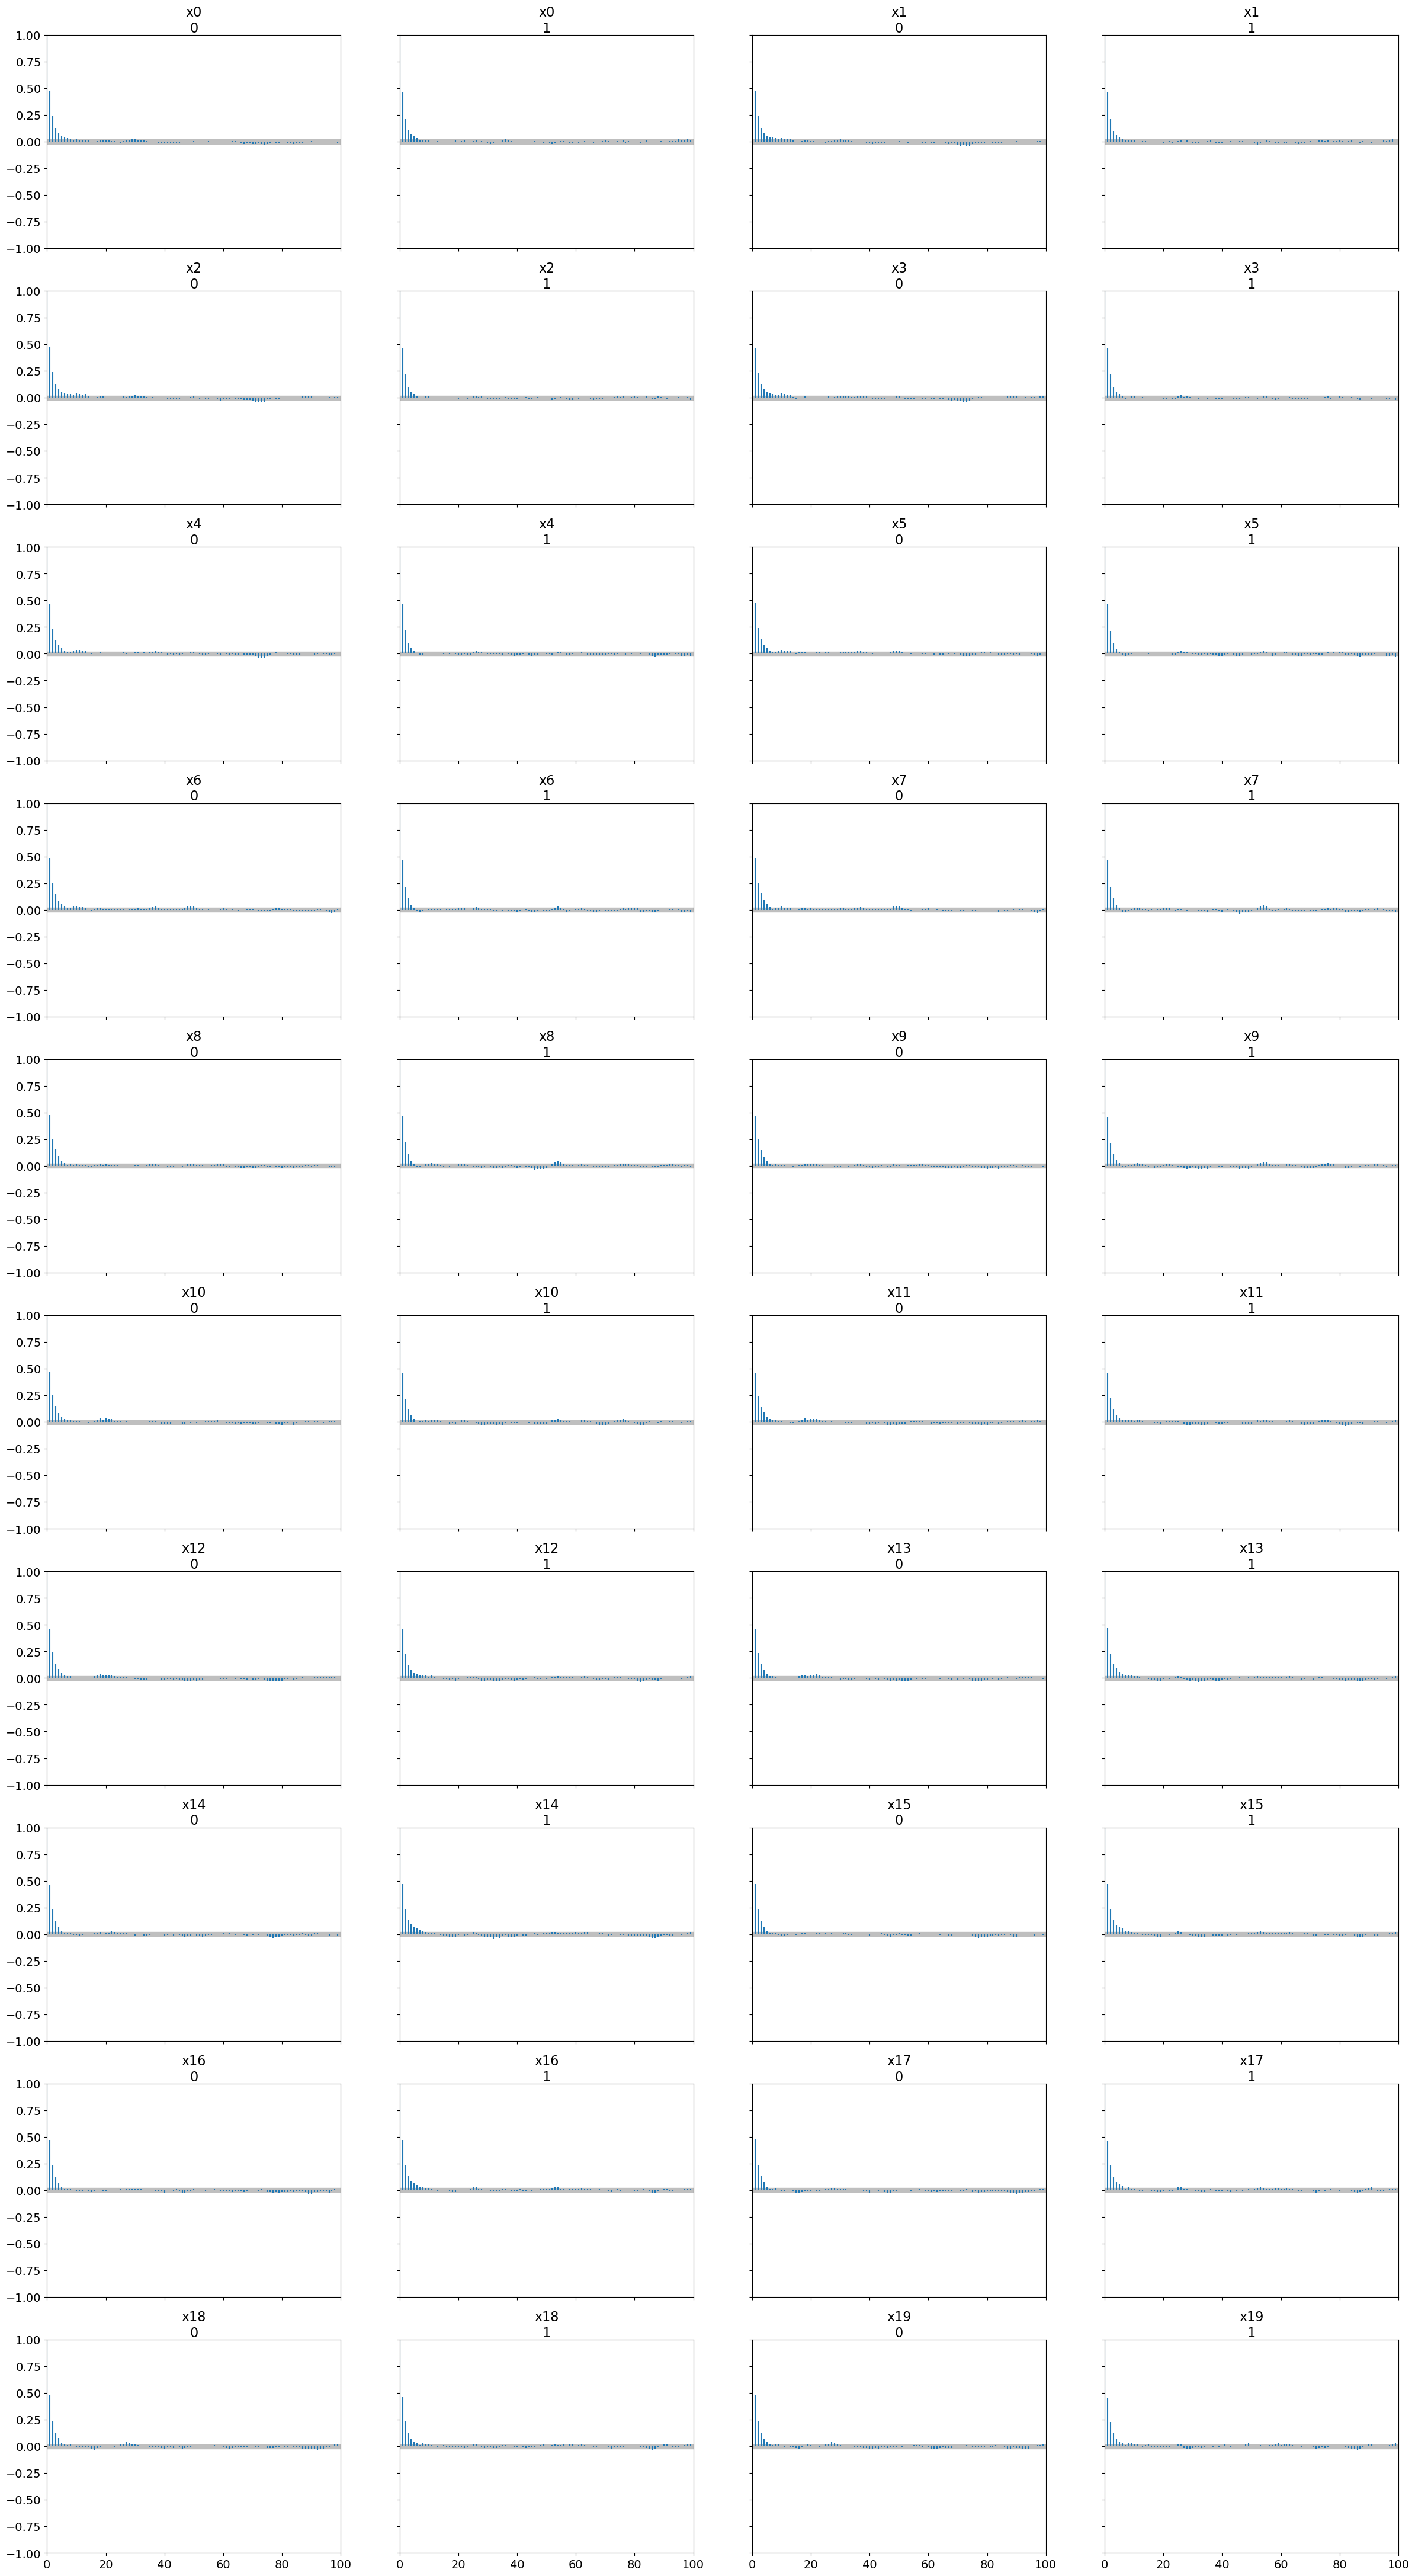

In [37]:
az.plot_autocorr(idata);

/home/dubois/miniconda3/envs/umbridge/lib/python3.12/site-packages/arviz/plots/plot_utils.py:272: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (100) in plot_posterior, generating only 40 plots
  warnings.warn(


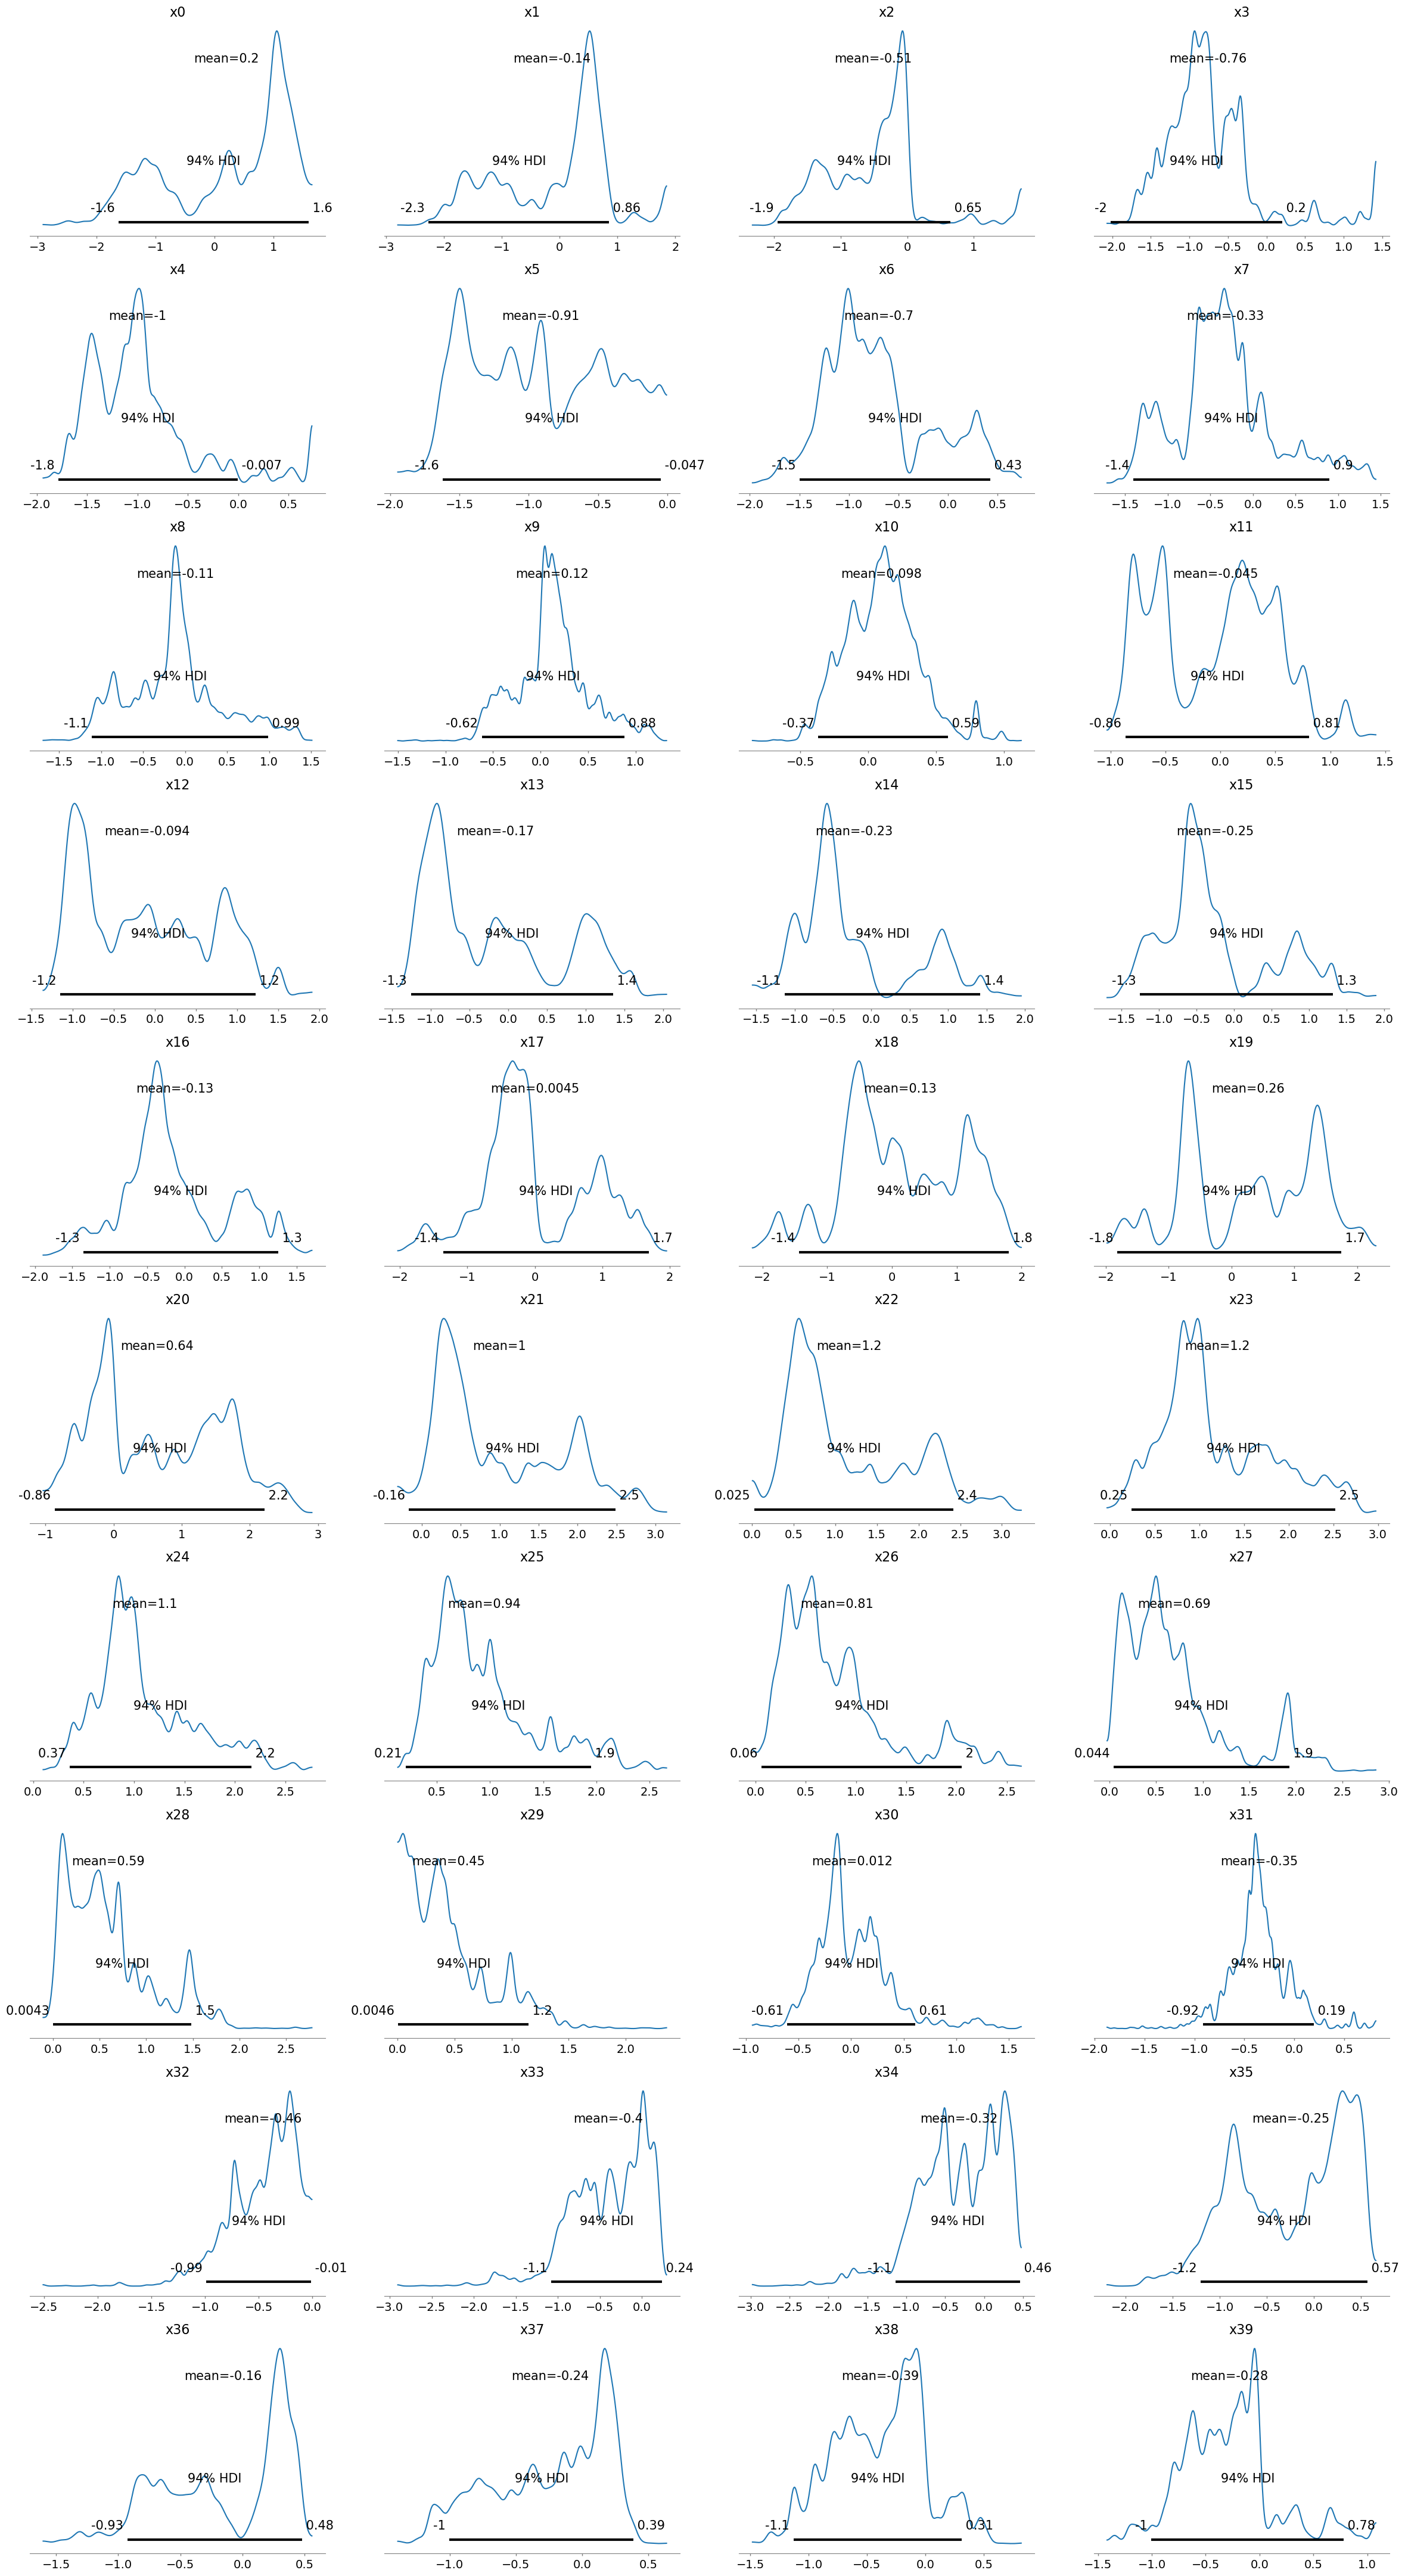

In [21]:
az.plot_posterior(idata);

/home/dubois/miniconda3/envs/umbridge/lib/python3.12/site-packages/arviz/plots/plot_utils.py:272: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (100) in plot_rank, generating only 40 plots
  warnings.warn(


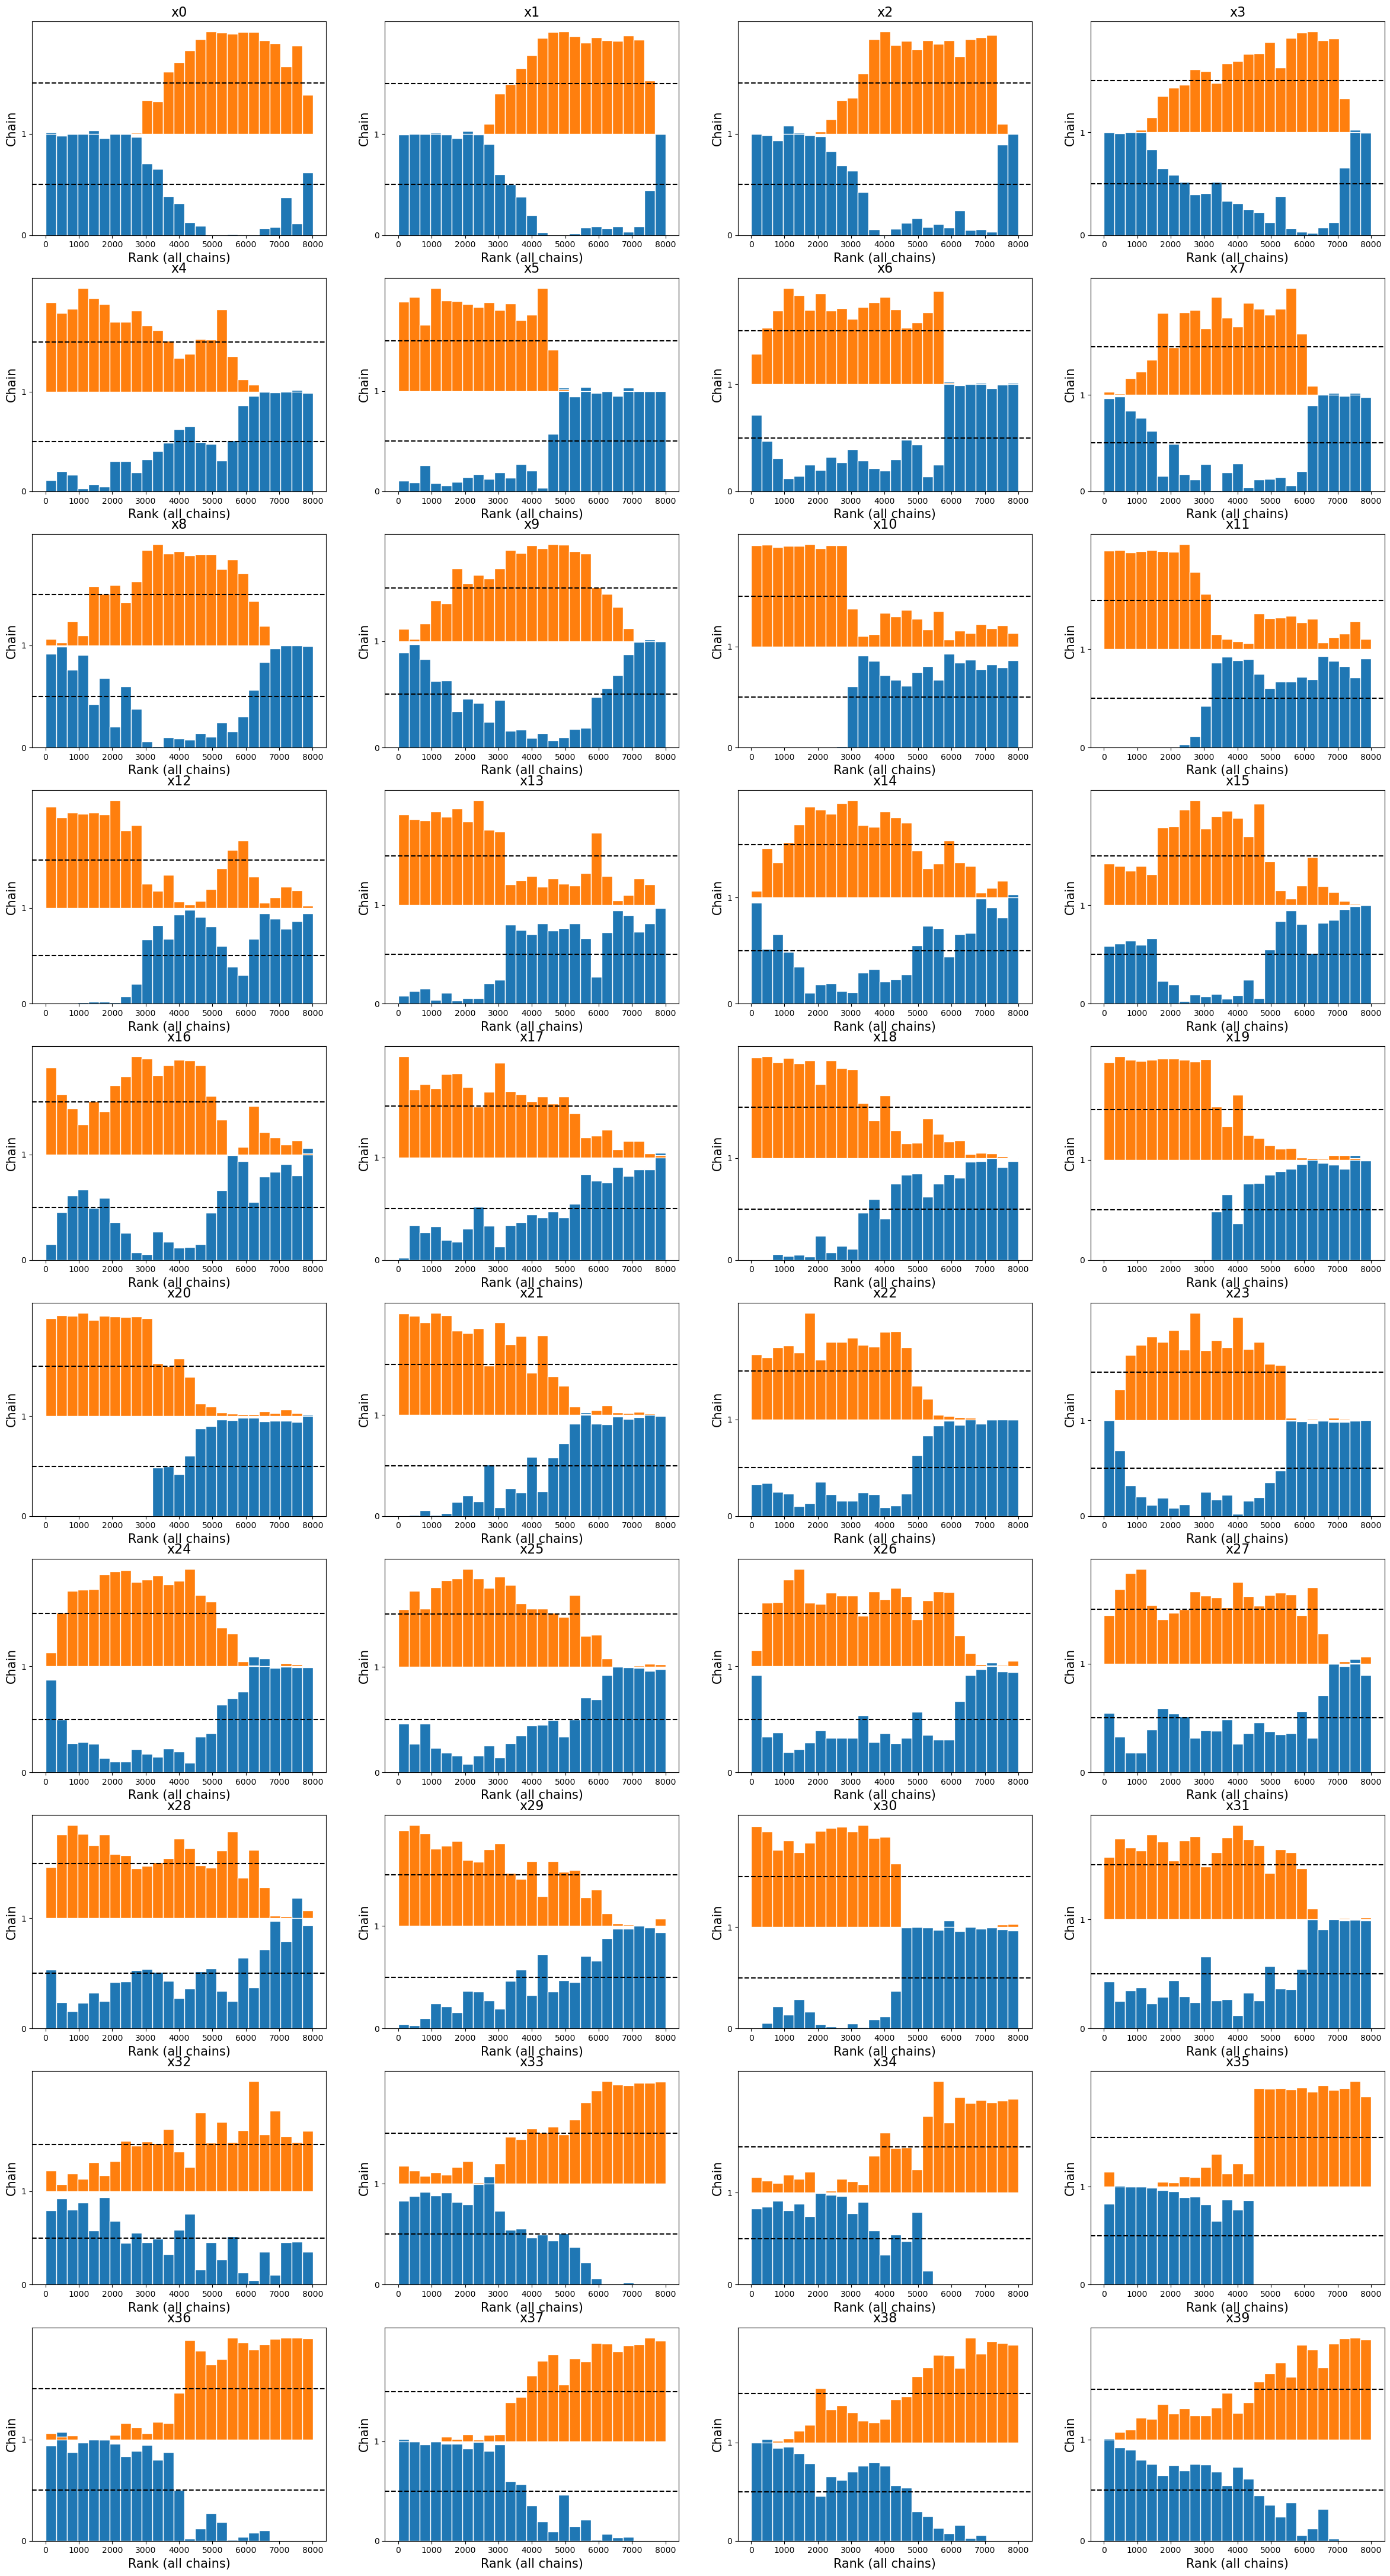

In [22]:
az.plot_rank(idata);

# Compare to true data

## Define model parameters

Note: for this part it would be better to get the results directly from the python script

In [81]:
# Set domain size and simulation time: this info is shared between the forward and parameter models 
Lx = 20
Lz = 1 
TEnd = 10 
H = 1.5

# Define sensors
# Each element of the list "captors" is a tuple of (x,z) coordinates. 
# Coordinates are given in the (scaled) domain: x \in [0, grid_size_x], z \in [0, grid_size_y]
sensors = [(4,0.8), (13.5, 0.6)]

# Create sorted sensor list to pass to the forward model: do not change this part 
sensors_sort = np.array(sensors, dtype=[('x',float),('y',float)])
sensors_sort = np.sort(sensors_sort, order=['x','y'])
sensors = sensors_sort.tolist()
n_sensors = len(sensors)
print("Number of sensors:", n_sensors)


nx, ny = 100, 202 # TODO: this can change based on the model 
print(f"input:{nx}, output:{ny}")

Number of sensors: 2
input:100, output:202


In [82]:
# Generate synthetic data
exact = np.zeros(nx)
# True source in the middle of the domain 
idx_middle = int(nx/2)
source_width = 4 # in length unit 
idx_width = int(0.5 * source_width / Lx * nx )
exact[idx_middle - idx_width : idx_middle + idx_width]=1

In [83]:
# Define functions to process the input of the model

# Level-set parameter
eps = 1e-6

def restriction(sampin):
    field_cut = sampin
    return (field_cut > eps).astype(int)

## Outputs where running the forward model is not needed

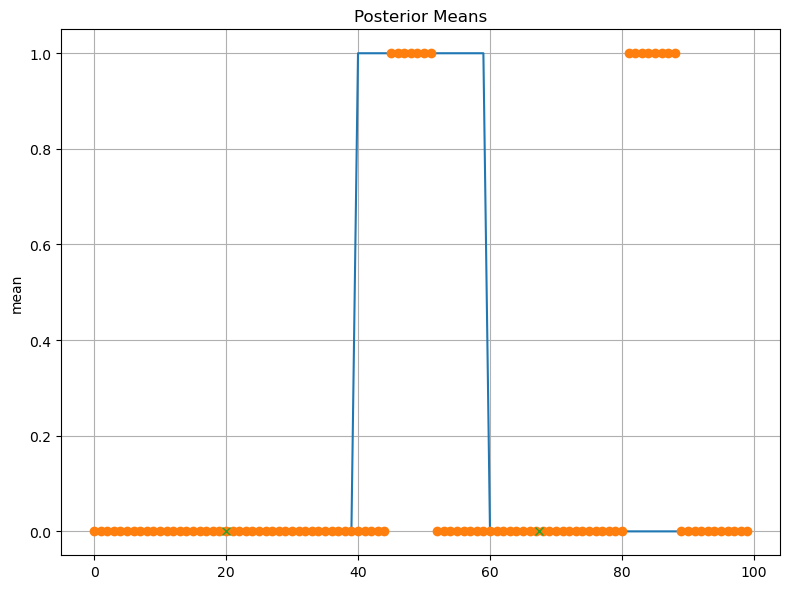

In [84]:
# Plot mean posterior against synthetic data
x = range(len(info))
plt.figure(figsize=(8, 6))
plt.plot(exact)
plt.title('Exact input')
plt.plot(x, restriction(info['mean']), 'o')  # x = index, y = mean
#plt.plot(x, info['mean'], 'x')  # x = index, y = mean
#print(top_links[0])
#plt.plot(x, restriction(parameters[top_indices[0]]), 'x')  # x = index, y = mean
plt.plot([sensors[0][0]*nx/Lx,sensors[1][0]*nx/Lx],[0,0],'x')
plt.ylabel('mean')
plt.title('Posterior Means')
plt.grid(True)
plt.tight_layout()
plt.show()

## Outputs where running the forward model is needed

In [70]:
# connect to the UM-Bridge model.
umbridge_model = umbridge.HTTPModel('http://localhost:4242', "forward")

# wrap the UM-Bridge model in the tinyDA UM-Bridge interface.
config = {"captors":sensors}

# my_model = tda.UmBridgeModel(umbridge_model) # DG: for now without config 
my_model = tda.UmBridgeModel(umbridge_model, umbridge_config=config)

# For now the DG file does not use the arg config 
nx = umbridge_model.get_input_sizes(config)[0] #the input is the value of f(x) at each grid point
ny = umbridge_model.get_output_sizes(config)[0] #the outout is a time series of the pressure

d_true = my_model(exact)

In [71]:
## Define functions needed 
def levelset_model(parameters):
    levelset_params = restriction(parameters)
    return my_model(levelset_params)


# GRF parameters
length_scale = 1
decay_rate = 10

# Use this covariance structure moving forward to match theory
def matern32_covariance(grid, length_scale, variance=1.0):
    dists = cdist(grid, grid, 'euclidean')
    sqrt3 = np.sqrt(3.0)
    scaled_dists = sqrt3 * dists / length_scale
    return variance * (1.0 + scaled_dists) * np.exp(-scaled_dists)


dx = Lx/nx
x = np.linspace(0, Lx, nx).reshape(-1, 1)
cov = matern32_covariance(x, length_scale)
cov += eps * np.eye(nx)
mean = np.zeros(nx)
my_prior = multivariate_normal(mean=mean, cov=cov)

### Compare draws from the posteriors to the true data

In [72]:
# Evaluate model outputs and likelihoods
n_samples = 10
ids = np.random.randint(0, len(parameters), n_samples)

likelihoods_post = []
outputs_post = []

for i in ids:
    param = parameters[i]
    output = levelset_model(param)
    outputs_post.append(output)
    idata_sub = idata.sel(draw=slice(None, None, subsampling_rate))
    loglikes = idata_sub.sample_stats["likelihood"].values.flatten()
    #print("Likelihood ", loglikes[i])
    likelihoods_post.append(loglikes[i])

# Normalize likelihoods for colormap
likelihoods_post = np.array(likelihoods_post)
norm = colors.Normalize(vmin=np.min(likelihoods_post), vmax=np.max(likelihoods_post))
cmap = cm.viridis  # Or any matplotlib colormap
colors_list = [cmap(norm(l)) for l in likelihoods_post]

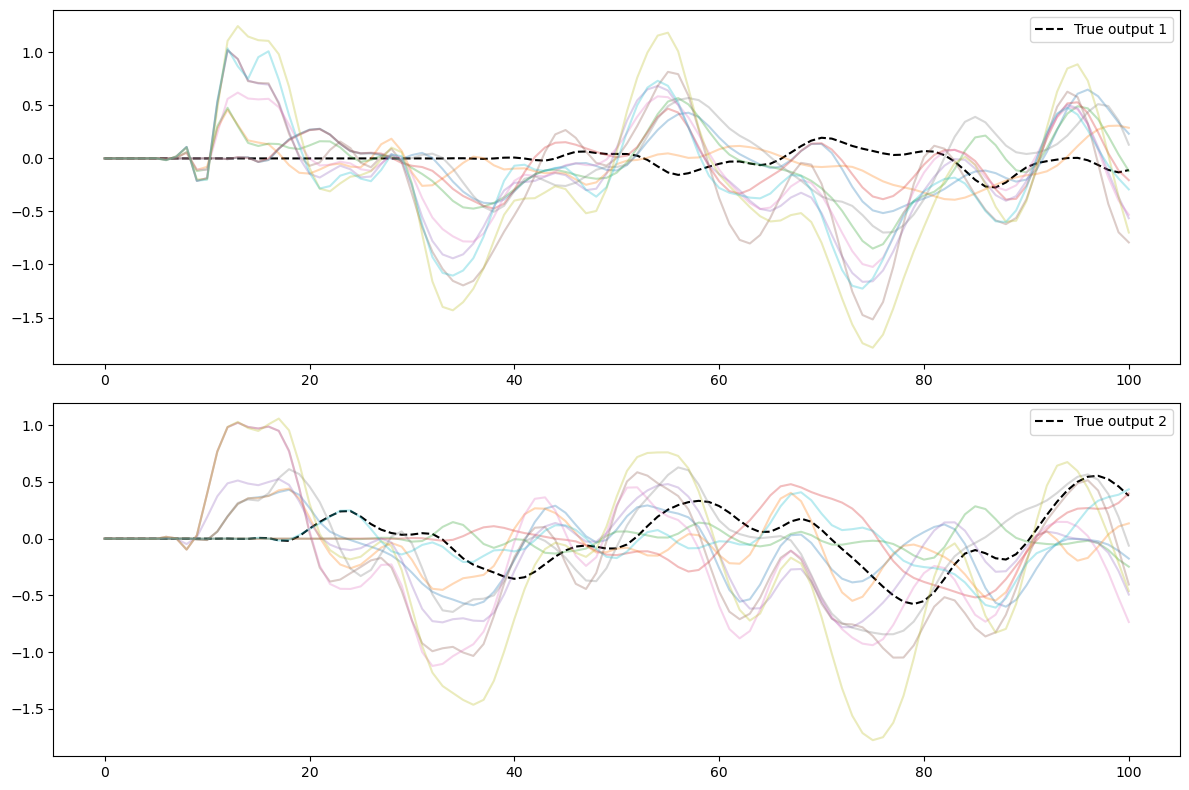

In [74]:
# Plot outputs
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

d_true = np.array(d_true)
ax[0].plot(d_true[::2], 'k--', label="True output 1")
ax[1].plot(d_true[1::2], 'k--', label="True output 2")
for output in outputs_post:
    ax[0].plot(output[::2], alpha=0.3)
    ax[1].plot(output[1::2], alpha=0.3)
   
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

IndexError: list index out of range

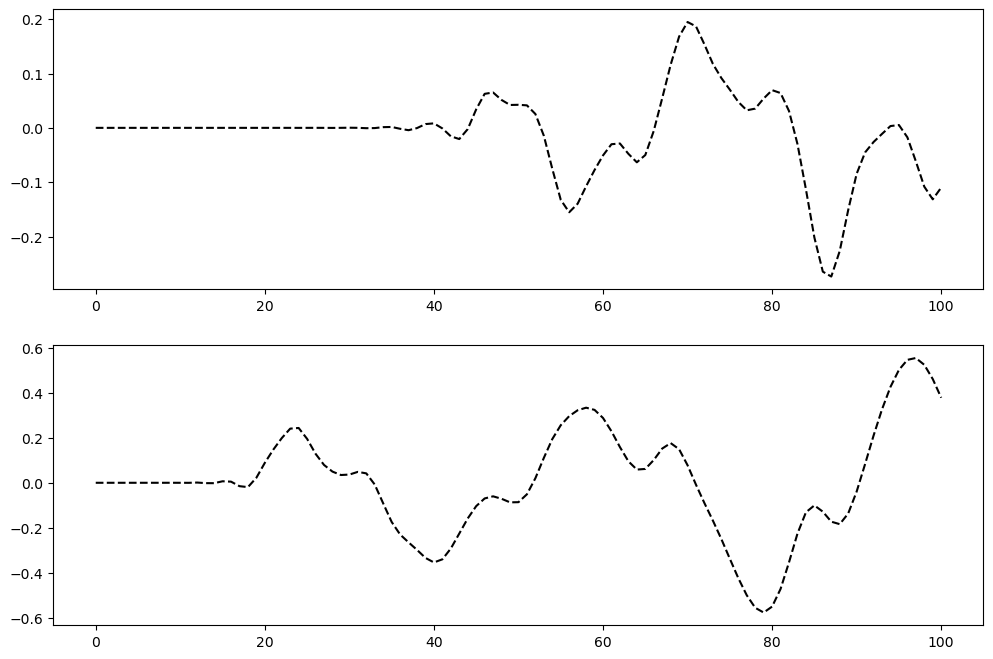

In [75]:
# Extract largest likelihoods for posterior
likelihoods = idata_sub.sample_stats["likelihood"].values[0, :]

# Sort parameter sets by decreasing likelihood
sorted_indices = np.argsort(-likelihoods)  # Negative for descending order
top_indices = sorted_indices[:5]

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

d_true = np.array(d_true)
ax[0].plot(d_true[::2], 'k--', label="True output 1")
ax[1].plot(d_true[1::2], 'k--', label="True output 2")

for i in top_indices:
    param = parameters[i]
    output = np.array(levelset_model(param))
    loglike = likelihoods[i]
    ax[0].plot(output[::2], alpha=0.3, label=f"loglike: {loglike:.2f}")
    ax[1].plot(output[1::2], alpha=0.3, label=f"loglike: {loglike:.2f}")

ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

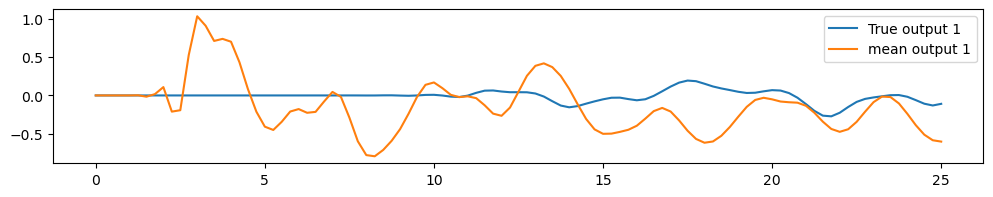

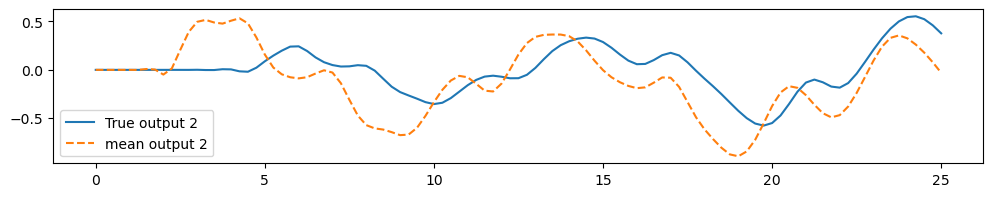

In [60]:
# Plot ouput from mean posterior
x=np.linspace(0,nx, nx)
t=np.linspace(0,25, int(ny/2))
d1 = np.array(d_true)[0:ny:2]
d2 = np.array(d_true)[1:ny:2]

output = levelset_model(info['mean'])
o1 = np.array(output)[0:ny:2]
o2 = np.array(output)[1:ny:2]

fig, ax = plt.subplots(figsize=(12,2))
ax.plot(t,d1, label='True output 1')
ax.plot(t,o1, label='mean output 1')
ax.legend()

fig, ax = plt.subplots(figsize=(12,2))
ax.plot(t,d2, label='True output 2')
ax.plot(t,o2, '--' ,label='mean output 2')
ax.legend()

### Compare draws from the prior to the true data

In [ ]:
# Evaluate model outputs and likelihoods
n_samples = 10

likelihoods_prior = []
outputs_prior = []

for ids in range(n_samples):
    log = my_prior.rvs()
    log = restriction(log)
    output = levelset_model(log)
    outputs_prior.append(output)
    idata_sub = idata.sel(draw=slice(None, None, subsampling_rate))
    loglikes = idata_sub.sample_stats["likelihood"].values.flatten()
    likelihoods_prior.append(loglikes[i])

# Normalize likelihoods for colormap
likelihoods_prior = np.array(likelihoods_prior)
norm = colors.Normalize(vmin=np.min(likelihoods_prior), vmax=np.max(likelihoods_prior))
cmap = cm.viridis  # Or any matplotlib colormap
colors_list = [cmap(norm(l)) for l in likelihoods_prior]


In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

d_true = np.array(d_true)
ax[0].plot(d_true[::2], 'k--', label="True output 1")
ax[1].plot(d_true[1::2], 'k--', label="True output 2")
for output in outputs_prior:
    ax[0].plot(output[::2], alpha=0.3)
    ax[1].plot(output[1::2], alpha=0.3)
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()